# Rice Type Classification

This notebook trains a small neural network on rice grain measurements. The goal is to practice a basic tabular classification workflow with PyTorch.


In [1]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

import torch

In [2]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import torch 
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
from torchinfo import summary
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [3]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

## Load and prepare the data

The CSV contains numeric grain features and a class label.


In [4]:
df = pd.read_csv('riceClassification.csv')
df.head()

,id,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,1,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796,1
1,2,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137,1
2,3,3048,76.293164,52.043491,0.731211,3132,62.296341,0.759153,210.012,0.868434,1.465950,1
3,4,3073,77.033628,51.928487,0.738639,3157,62.551300,0.783529,210.657,0.870203,1.483456,1
4,5,3693,85.124785,56.374021,0.749282,3802,68.571668,0.769375,230.332,0.874743,1.510000,1


In [5]:
df.dropna(inplace=True)
df.drop(columns='id', inplace=True)
print(df.shape)
df.head()

(18185, 11)


,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796,1
1,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137,1
2,3048,76.293164,52.043491,0.731211,3132,62.296341,0.759153,210.012,0.868434,1.465950,1
3,3073,77.033628,51.928487,0.738639,3157,62.551300,0.783529,210.657,0.870203,1.483456,1
4,3693,85.124785,56.374021,0.749282,3802,68.571668,0.769375,230.332,0.874743,1.510000,1


In [6]:
df["Class"].value_counts()

Class
1    9985
0    8200
Name: count, dtype: int64

In [7]:
original_df = df.copy()
for col in df.columns :
    df[col] = df[col] / df[col].abs().max()
df.head()
    

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,0.444368,0.503404,0.775435,0.744658,0.424873,0.666610,0.741661,0.537029,0.844997,0.368316,1.0
1,0.281293,0.407681,0.622653,0.750489,0.273892,0.530370,0.804230,0.409661,0.919215,0.371471,1.0
2,0.298531,0.416421,0.630442,0.756341,0.284520,0.546380,0.856278,0.412994,0.959862,0.374747,1.0
3,0.300979,0.420463,0.629049,0.764024,0.286791,0.548616,0.883772,0.414262,0.961818,0.379222,1.0
4,0.361704,0.464626,0.682901,0.775033,0.345385,0.601418,0.867808,0.452954,0.966836,0.386007,1.0


In [8]:
X = np.array(df.iloc[:, :-1])
y = np.array(df.iloc[:, -1])
X

array([[0.44436827, 0.50340371, 0.77543522, ..., 0.5370287 , 0.844997  ,
        0.36831616],
       [0.28129285, 0.40768133, 0.62265269, ..., 0.40966075, 0.91921498,
        0.37147093],
       [0.29853085, 0.41642141, 0.63044229, ..., 0.41299402, 0.95986205,
        0.37474651],
       ...,
       [0.62340842, 0.84480035, 0.64091576, ..., 0.67304935, 0.75472018,
        0.74783024],
       [0.58374143, 0.8263563 , 0.62355087, ..., 0.67524793, 0.70210346,
        0.75187447],
       [0.60078355, 0.83554818, 0.62495614, ..., 0.6658912 , 0.74305096,
        0.7585284 ]])

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,       random_state=42)

In [10]:
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size=0.5,       random_state=42)

In [11]:
X_train.shape, X_test.shape, X_val.shape

((12729, 10), (2728, 10), (2728, 10))

## Build the PyTorch dataset

The arrays are wrapped so they can be used with DataLoader.


In [12]:
class dataset(Dataset):
    def __init__(self,
                X,
                y):
        self.X = torch.tensor(X, dtype = torch.float32).to(device)
        self.y = torch.tensor(y, dtype = torch.float32).to(device)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]        

In [13]:
train_data = dataset(X_train, y_train)
val_data = dataset(X_val, y_val)
test_data = dataset(X_test, y_test)

In [14]:
train_dataloader = DataLoader(train_data,
                             batch_size = 8,
                             shuffle = True)
test_dataloader = DataLoader(test_data,
                             batch_size = 8,
                             shuffle = False)
val_dataloader = DataLoader(val_data,
                             batch_size = 8,
                             shuffle = True)

## Train a small model

A simple feed-forward network is enough for this binary example.


In [15]:
class Zed(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(X.shape[1], 10),
            nn.Sigmoid(),
            nn.Linear(10, 1),
            nn.Sigmoid()
        )

    def forward(self, X):
        return self.network(X)

In [16]:
model = Zed().to(device)
summary(model, (X.shape[1],))

Layer (type:depth-idx)                   Output Shape              Param #
Zed                                      [1]                       --
├─Sequential: 1-1                        [1]                       --
│    └─Linear: 2-1                       [10]                      110
│    └─Sigmoid: 2-2                      [10]                      --
│    └─Linear: 2-3                       [1]                       11
│    └─Sigmoid: 2-4                      [1]                       --
Total params: 121
Trainable params: 121
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00

In [17]:
loss_fn = nn.BCELoss()
optimizer = Adam(params = model.parameters(),
                lr = 1e-3)

In [18]:
total_loss_train_plot = []
total_loss_val_plot = []
total_acc_train_plot = []
total_acc_val_plot = []

epochs = 10

for epoch in range(epochs):
    total_acc_train = 0
    total_loss_train = 0
    total_acc_val = 0
    total_loss_val = 0

    for data in train_dataloader:
        inputs, labels = data

        preds = model(inputs).squeeze(1)
        batch_loss = loss_fn(preds, labels)
        total_loss_train += batch_loss.item()

        acc = ((preds).round() == labels).sum().item()
        total_acc_train += acc

        batch_loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    with torch.inference_mode():
        for data in val_dataloader:
            inputs, labels = data
            preds = model(inputs).squeeze(1)
            batch_loss = loss_fn(preds, labels)
            total_loss_val += batch_loss.item()

            acc = ((preds).round() == labels).sum().item()
            total_acc_val += acc

    total_loss_train_plot.append(round(total_loss_train / len(train_dataloader), 4))
    total_loss_val_plot.append(round(total_loss_val / len(val_dataloader), 4))

    total_acc_train_plot.append(round(total_acc_train / len(train_data) * 100, 4))
    total_acc_val_plot.append(round(total_acc_val / len(val_data) * 100, 4))

    if epoch % 10 == 0:
        print(f'''Epoch : {epoch} | train loss: {total_loss_train_plot[-1]} | train accuracy : {total_acc_train_plot[-1]}
        validation loss : {total_loss_val_plot[-1]} | validation accuracy : {total_acc_val_plot[-1]}''')
        print("=" * 21)

Epoch : 0 | train loss: 0.6592 | train accuracy : 62.7072
        validation loss : 0.5772 | validation accuracy : 95.3079


## Evaluate the model

The test split gives a quick check on unseen rows.


In [19]:
with torch.inference_mode():
    total_loss_test = 0
    total_acc_test = 0
    for data in test_dataloader:
        inputs, labels = data
        preds = model(inputs).squeeze(1)

        batch_loss = loss_fn(preds, labels).item()
        total_loss_test += batch_loss

        acc = ((preds).round() == labels).sum().item()
        total_acc_test += acc

print(f'Test loss: {round(total_loss_test / len(test_dataloader), 4)}')
print(f'Test accuracy: {round(total_acc_test / len(test_data) * 100, 4)}%')

Test loss: 0.0359
Test accuracy: 98.827%


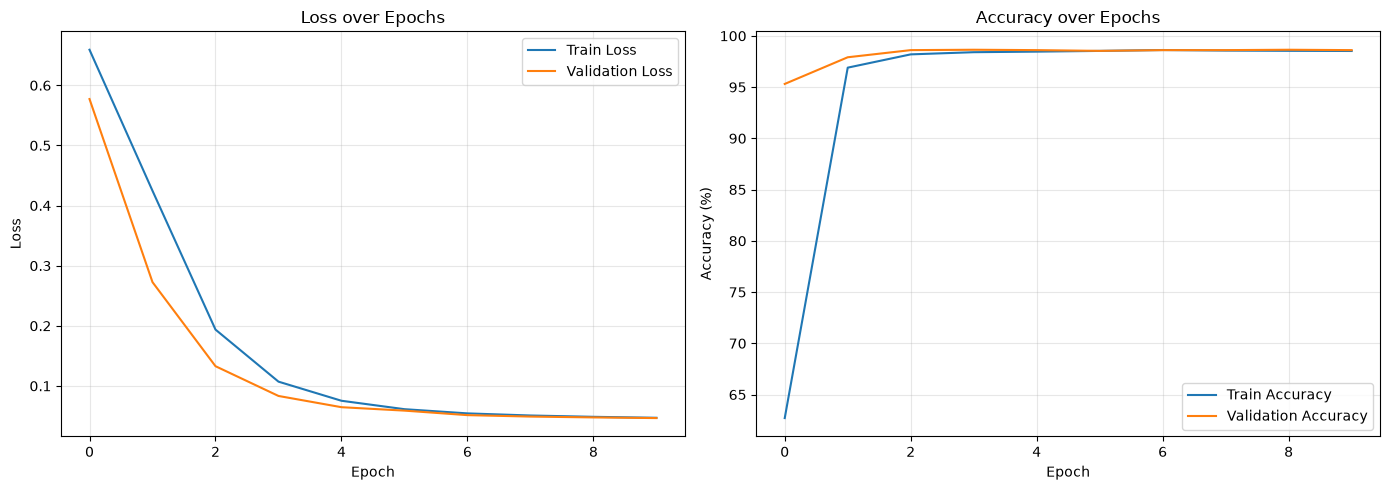

In [20]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(len(total_loss_train_plot))

axs[0].plot(epochs_range, total_loss_train_plot, label='Train Loss')
axs[0].plot(epochs_range, total_loss_val_plot, label='Validation Loss')
axs[0].set_title('Loss over Epochs')
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Loss')
axs[0].legend()
axs[0].grid(True, alpha=0.3)


axs[1].plot(epochs_range, total_acc_train_plot, label='Train Accuracy')
axs[1].plot(epochs_range, total_acc_val_plot, label='Validation Accuracy')
axs[1].set_title('Accuracy over Epochs')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Accuracy (%)')
axs[1].legend()
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Try one manual prediction

This final cell shows how a single sample can be normalized and passed to the model.


In [21]:
Area = 1212/original_df['Area'].max()
MajorAxisLength = 3334/original_df['MajorAxisLength'].max()
MinorAxisLength = 56/original_df['MinorAxisLength'].max()
Eccentricity = 98/original_df['Eccentricity'].max()
ConvexArea = 123/original_df['ConvexArea'].max()
EquivDiameter = 909/original_df['EquivDiameter'].max()
Extent = 32/original_df['Extent'].max()
Perimeter = 66/original_df['Perimeter'].max()
Roundness = 12/original_df['Roundness'].max()
AspectRation = 87/original_df['AspectRation'].max()

sample = torch.tensor(
    [Area, MajorAxisLength, MinorAxisLength, Eccentricity, ConvexArea,
     EquivDiameter, Extent, Perimeter, Roundness, AspectRation],
    dtype=torch.float32
).to(device)

model.eval()
with torch.inference_mode():
    prediction = model(sample)

print(prediction.item())


0.9999951124191284


In [22]:
original_df.head()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796,1
1,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137,1
2,3048,76.293164,52.043491,0.731211,3132,62.296341,0.759153,210.012,0.868434,1.465950,1
3,3073,77.033628,51.928487,0.738639,3157,62.551300,0.783529,210.657,0.870203,1.483456,1
4,3693,85.124785,56.374021,0.749282,3802,68.571668,0.769375,230.332,0.874743,1.510000,1
